In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/despesas_ma_2025_pagamentos.csv", sep=",")

C:\Users\edils\AppData\Local\Temp\ipykernel_22680\990760337.py:1: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/despesas_ma_2025_pagamentos.csv", sep=",")


In [3]:
qtd_linhas , qtd_colunas = df.shape
print(f"Quantidade de {qtd_linhas} linhas \nQuantidade de {qtd_colunas} colunas")

Quantidade de 506467 linhas 
Quantidade de 12 colunas


In [4]:
df_colunas = df.columns
for colunas in df_colunas:
    print(f"Coluna - {colunas}")

Coluna - Unnamed: 0
Coluna - ano
Coluna - mes
Coluna - fase
Coluna - codigo_unidade
Coluna - unidade
Coluna - valor
Coluna - codigo_credor
Coluna - credor_nome
Coluna - codigo_funcao
Coluna - codigo_natureza
Coluna - cod_grupo_despesa


In [5]:
#df = df.drop(columns=["Unnamed: 0"])

df_benford = df[df["valor"] > 0].copy()

df_benford = df[["ano", "mes", "codigo_credor", "credor_nome", "valor"]]

display(df_benford.sample(5))

,ano,mes,codigo_credor,credor_nome,valor
475572,2025,12,00000PF0000117,AUXÃLIO - PERMANÃNCIA,5000.0
243883,2025,7,00000PJ0000201,PROGRAMA TRABALHO JOVEM,150000.0
398858,2025,11,05057657000109,AGENCIA ESTADUAL DE DEFESA AGROPECUARIA,695505.0
127254,2025,5,05289160000116,JUNTA COMERCIAL DO MARANHAO,172897.0
347852,2025,10,00000PF0000054,BOLSISTAS,25500.0


In [6]:
valores = df_benford['valor'].values
print(valores)

[ 164832.  162405.  432708. ... 3134933. 1626707.  706131.]


$$
N = \frac{x}{10^{\lfloor \log_{10}(x) \rfloor}}
$$

In [7]:
norm = valores / 10 ** np.floor(np.log10(valores))
print(norm)

[1.64832  1.62405  4.32708  ... 3.134933 1.626707 7.06131 ]


$$
1 \le N < 10
$$

In [8]:
for k, nome in enumerate(
    ["primeiro_digito","segundo_digito","terceiro_digito", "quarto_digito"],
    start=1
):
    df_benford[nome] = np.floor((norm * 10**(k-1)) % 10).astype("uint8")

C:\Users\edils\AppData\Local\Temp\ipykernel_22680\1290290572.py:5: RuntimeWarning: invalid value encountered in cast
  df_benford[nome] = np.floor((norm * 10**(k-1)) % 10).astype("uint8")
C:\Users\edils\AppData\Local\Temp\ipykernel_22680\1290290572.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benford[nome] = np.floor((norm * 10**(k-1)) % 10).astype("uint8")
C:\Users\edils\AppData\Local\Temp\ipykernel_22680\1290290572.py:5: RuntimeWarning: invalid value encountered in cast
  df_benford[nome] = np.floor((norm * 10**(k-1)) % 10).astype("uint8")
C:\Users\edils\AppData\Local\Temp\ipykernel_22680\1290290572.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

$$
d_k =
\left\lfloor
\left(
N \times 10^{k-1}
\right)
\bmod 10
\right\rfloor
$$

### Lei de Benford 

In [9]:
display(df_benford)

,ano,mes,codigo_credor,credor_nome,valor,primeiro_digito,segundo_digito,terceiro_digito,quarto_digito
0,2025,1,29485582000125,"FP- PROJETOS, GERENCIAMENTOS, SERVIÃOS E EMPR...",164832.0,1,6,4,8
1,2025,1,29485582000125,"FP- PROJETOS, GERENCIAMENTOS, SERVIÃOS E EMPR...",162405.0,1,6,2,4
2,2025,1,14151000000288,C & S VIGILÃNCIA E SEGURANÃA PATRIMONIAL EIRELI,432708.0,4,3,2,7
3,2025,1,23361040000164,CASTELUCCI EMPREENDIMENTOS E SERVIÃOS GERAIS ...,20402.0,2,0,4,0
4,2025,1,00000PF0000031,INDENIZACAO VALE TRANSPORTE,1092.0,1,0,9,2
...,...,...,...,...,...,...,...,...,...
506462,2025,12,46777118000121,SECRETARIA DE ESTADO DA PESCA E AQUICULTURA DO...,71592.0,7,1,5,9
506463,2025,12,46777118000121,SECRETARIA DE ESTADO DA PESCA E AQUICULTURA DO...,10768794.0,1,0,7,6
506464,2025,12,46777118000121,SECRETARIA DE ESTADO DA PESCA E AQUICULTURA DO...,3134933.0,3,1,3,4
506465,2025,12,46777118000121,SECRETARIA DE ESTADO DA PESCA E AQUICULTURA DO...,1626707.0,1,6,2,6


#### 1º Digito

In [10]:
minino_benford = df_benford['primeiro_digito'].min()
maximo_benford = df_benford['primeiro_digito'].max()

print(f"valor minimo é: {minino_benford}\nValor máximo é: {maximo_benford} ")

valor minimo é: 0
Valor máximo é: 9 


In [32]:
df_benford_d1 = df_benford[df_benford["primeiro_digito"]>0]
df_benford_d1

minino_benford = df_benford_d1['primeiro_digito'].min()
maximo_benford = df_benford_d1['primeiro_digito'].max()

print(f"valor minimo é: {minino_benford}\nValor máximo é: {maximo_benford} ")

valor minimo é: 1
Valor máximo é: 9 


In [33]:
frequencia_real = (
    df_benford_d1["primeiro_digito"]
    .value_counts()
    .sort_index()
)

display(frequencia_real)

primeiro_digito
1    137231
2     89384
3     63060
4     46036
5     43593
6     38976
7     44996
8     19346
9     23838
Name: count, dtype: int64

In [13]:
n_d1 = frequencia_real.sum()
display(n_d1)

np.int64(506460)

In [14]:
percentual_real = frequencia_real / n_d1
display(percentual_real)

primeiro_digito
1    0.270961
2    0.176488
3    0.124511
4    0.090898
5    0.086074
6    0.076958
7    0.088844
8    0.038198
9    0.047068
Name: count, dtype: float64

In [15]:
digitos = np.arange(1,10)
display(digitos)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [16]:
percentual_benford = np.log10(1+1/digitos)
display(percentual_benford)

array([0.30103   , 0.17609126, 0.12493874, 0.09691001, 0.07918125,
       0.06694679, 0.05799195, 0.05115252, 0.04575749])

In [17]:
frequencia_benford = percentual_benford * n_d1
display(frequencia_benford)

array([152459.65160398,  89183.17906134,  63276.47254264,  49081.04518806,
        40102.13387328,  33905.87107632,  29370.60146632,  25906.7065187 ,
        23174.33866936])

In [18]:
z_score = (
    np.abs(percentual_real.values - percentual_benford)
    / np.sqrt((percentual_benford * (1 - percentual_benford)) / n_d1)
)
display(z_score)

array([46.65033   ,  0.74084604,  0.91994626, 14.46343097, 18.16612821,
       28.50547904, 93.939312  , 41.84526326,  4.46286201])

In [19]:
chi2_parcial = (frequencia_real.values - frequencia_benford) ** 2 / frequencia_benford
chi2_total = chi2_parcial.sum()


print(f'Qui-quadrado parcial:{chi2_parcial}')
print(f'Qui-quadrado Total: {chi2_total}')


Qui-quadrado parcial:[1.52113577e+03 4.52204663e-01 7.40565329e-01 1.88918149e+02
 3.03877753e+02 7.58163896e+02 8.31283893e+03 1.66145666e+03
 1.90057791e+01]
Qui-quadrado Total: 12766.5897071482


In [20]:
ks = np.max(
    np.abs(
        np.cumsum(percentual_real.values)
        - np.cumsum(percentual_benford)
    )
)

display(ks)


np.float64(0.036112128097026575)

In [21]:
mad = np.mean(np.abs(percentual_real.values - percentual_benford))
display(mad)

np.float64(0.010991709712023102)

In [35]:
tabela_1d = pd.DataFrame({
    "Frequencia Esperada": frequencia_benford.astype(int),
    "Frequencia Esperada (%)": percentual_benford*100,
    "Frequencia Real": frequencia_real.values,
    "Frequencia Real (%)": percentual_real*100,
    "Teste_Z": z_score,
    "Qui-Quadrado": chi2_parcial
})

display(tabela_1d)


,Frequencia Esperada,Frequencia Esperada (%),Frequencia Real,Frequencia Real (%),Teste_Z,Qui-Quadrado
primeiro_digito,,,,,,
1,152459,30.103000,137231,27.096118,46.650330,1521.135771
2,89183,17.609126,89384,17.648778,0.740846,0.452205
3,63276,12.493874,63060,12.451131,0.919946,0.740565
4,49081,9.691001,46036,9.089760,14.463431,188.918149
5,40102,7.918125,43593,8.607392,18.166128,303.877753
6,33905,6.694679,38976,7.695771,28.505479,758.163896
7,29370,5.799195,44996,8.884413,93.939312,8312.838932
8,25906,5.115252,19346,3.819848,41.845263,1661.456658
9,23174,4.575749,23838,4.706788,4.462862,19.005779


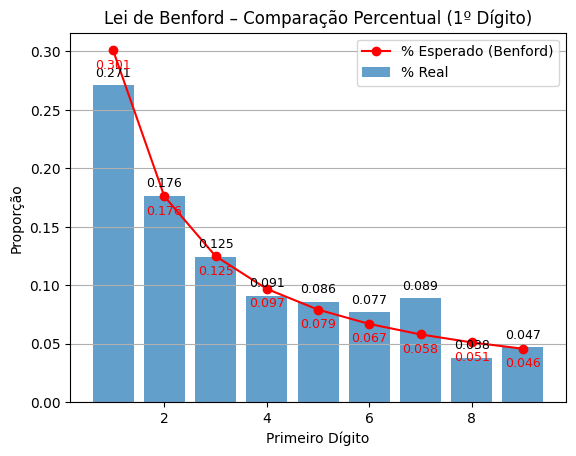

In [27]:
plt.figure()

# Barras – % real
bars = plt.bar(
    digitos,
    percentual_real.values,
    label='% Real',
    alpha=0.7
)

# Linha – % esperado (Benford) em vermelho
plt.plot(
    digitos,
    percentual_benford,
    marker='o',
    linestyle='-',
    color='red',
    label='% Esperado (Benford)'
)

# ============================
# Rótulos nas barras (% real)
# ============================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,          # deslocamento vertical
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ============================
# Rótulos na linha (% Benford)
# ============================
for x, y in zip(digitos, percentual_benford):
    plt.text(
        x,
        y - 0.007,               # deslocamento para baixo
        f'{y:.3f}',
        ha='center',
        va='top',
        fontsize=9,
        color='red'
    )

# Configurações finais
plt.xlabel('Primeiro Dígito')
plt.ylabel('Proporção')
plt.title('Lei de Benford – Comparação Percentual (1º Dígito)')
plt.legend()
plt.grid(axis='y')

plt.show()
